In [1]:
# xarray to read NETCDF
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
import dask as dd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
plt.rcParams['figure.dpi'] = 300

In [4]:
sst = xr.open_dataset('data/SST/sst.mnmean.nc')
sst = sst.assign_coords(lon=(((sst.lon + 180) % 360) - 180)).sortby(['lon'])
sst_df = sst.to_dataframe().reset_index()
sst_df = sst_df[sst_df['nbnds'] == 0]

In [5]:
sst_df

,lat,time,nbnds,lon,time_bnds,sst
0,88.0,1854-01-01,0,-180.0,9.969210e+36,-1.8
1,88.0,1854-01-01,0,-178.0,9.969210e+36,-1.8
2,88.0,1854-01-01,0,-176.0,9.969210e+36,-1.8
3,88.0,1854-01-01,0,-174.0,9.969210e+36,-1.8
4,88.0,1854-01-01,0,-172.0,9.969210e+36,-1.8
...,...,...,...,...,...,...
65777935,-88.0,2025-01-01,0,170.0,9.969210e+36,NaN
65777936,-88.0,2025-01-01,0,172.0,9.969210e+36,NaN
65777937,-88.0,2025-01-01,0,174.0,9.969210e+36,NaN
65777938,-88.0,2025-01-01,0,176.0,9.969210e+36,NaN


In [6]:
chirps = xr.open_dataset('data/CHIRPS/chirps-v2.0.monthly.nc')

In [7]:
sst_df['month'] = sst_df['time'].dt.month
sst_df['year'] = sst_df['time'].dt.year

In [9]:
chirps_eastern_east_africa = chirps.sel(latitude=slice(-3.5, 8), longitude=slice(38, 50)).to_dataframe().reset_index()
chirps_eastern_east_africa['month'] = chirps_eastern_east_africa['time'].dt.month
chirps_eastern_east_africa['year'] = chirps_eastern_east_africa['time'].dt.year

In [10]:
chirps_eastern_east_africa_jan = chirps_eastern_east_africa.query('month == 1').groupby(['month', 'year']).mean('precip').reset_index()

In [11]:
start_year = 1993
end_year = 2024

# Create a boolean mask
mask = (chirps_eastern_east_africa_jan['year'] >= start_year) & (chirps_eastern_east_africa_jan['year'] <= end_year)

# Apply the mask to filter the DataFrame
chirps_eastern_east_africa_jan = chirps_eastern_east_africa_jan[mask]

In [12]:
chirps_eastern_east_africa_jan.quantile([0.33, 0.66])

,month,year,latitude,longitude,precip
0.33,1.0,2003.23,2.249998,43.999996,4.167859
0.66,1.0,2013.46,2.249998,43.999996,6.129906


In [13]:
jan_bn = chirps_eastern_east_africa_jan.query('precip <= 4.16786')['year'].to_list()

In [14]:
jan_n = chirps_eastern_east_africa_jan.query('4.16786 <= precip <= 6.12991')['year'].to_list()

In [15]:
jan_an = chirps_eastern_east_africa_jan.query('6.12991 <= precip')['year'].to_list()

In [16]:
ltm_sst = sst_df.dropna().groupby(['lat', 'lon', 'month']).mean('sst').reset_index()
ltm_sst_clean = ltm_sst.drop(['time_bnds', 'nbnds', 'year'], axis=1)
ltm_sst_clean = ltm_sst_clean.rename(columns={'sst':'ltm_sst'})

In [17]:
sst_anomaly = sst_df.drop(['time_bnds', 'nbnds'], axis=1).merge(ltm_sst_clean, on=['lat', 'lon', 'month'], how='left')
mask = (sst_anomaly['year'] >= start_year) & (sst_anomaly['year'] <= end_year)

sst_anomaly = sst_anomaly[mask].reset_index().drop(['index'], axis=1)

In [18]:
sst_anomaly['sst_anomaly'] = sst_anomaly['sst'] - sst_anomaly['ltm_sst']

In [19]:
sst_anomaly

,lat,time,lon,sst,month,year,ltm_sst,sst_anomaly
0,88.0,1993-01-01,-180.0,-1.8,1,1993,-1.8,1.192093e-07
1,88.0,1993-01-01,-178.0,-1.8,1,1993,-1.8,1.192093e-07
2,88.0,1993-01-01,-176.0,-1.8,1,1993,-1.8,1.192093e-07
3,88.0,1993-01-01,-174.0,-1.8,1,1993,-1.8,1.192093e-07
4,88.0,1993-01-01,-172.0,-1.8,1,1993,-1.8,1.192093e-07
...,...,...,...,...,...,...,...,...
6151675,-88.0,2024-12-01,170.0,NaN,12,2024,NaN,NaN
6151676,-88.0,2024-12-01,172.0,NaN,12,2024,NaN,NaN
6151677,-88.0,2024-12-01,174.0,NaN,12,2024,NaN,NaN
6151678,-88.0,2024-12-01,176.0,NaN,12,2024,NaN,NaN


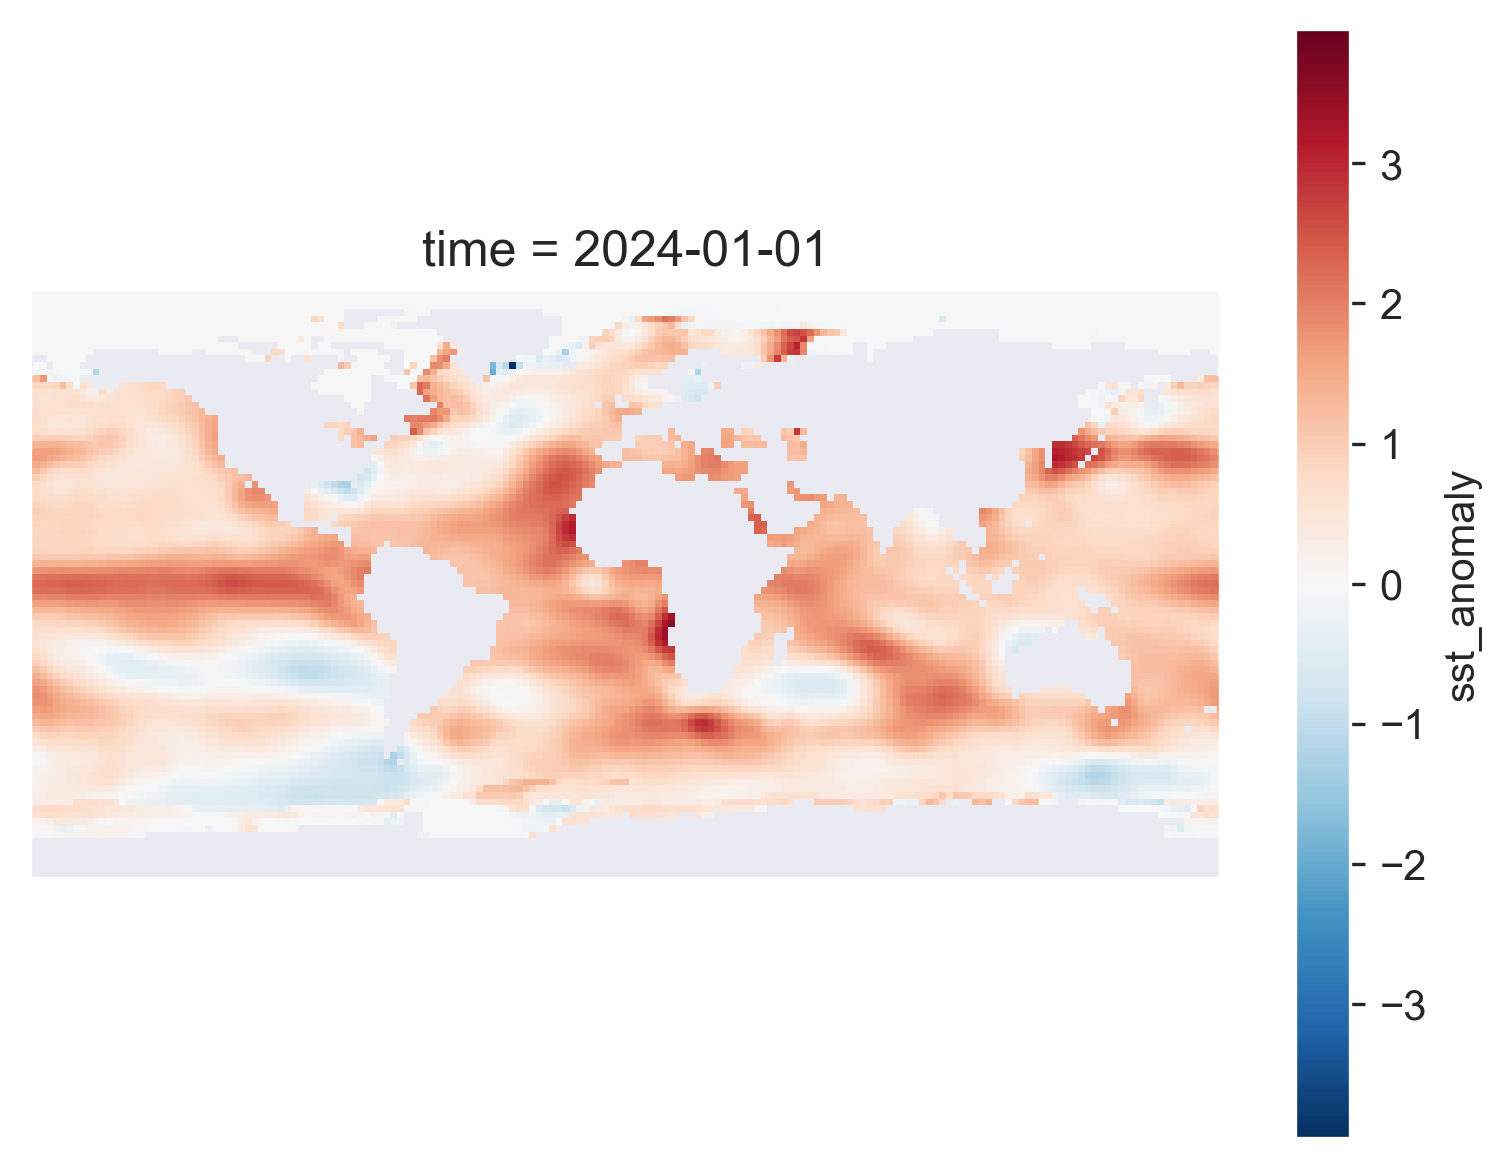

In [26]:
sst_anomaly.drop(['month', 'year'], axis=1).set_index(['lat', 'lon', 'time']).to_xarray().sel(time='2024-01')['sst_anomaly'].plot(
    subplot_kws=dict(projection=ccrs.PlateCarree()),
    transform=ccrs.PlateCarree()
)
plt.savefig('figures/global_sst/sst_jan_2024.png')

In [30]:
sst_anomaly_jan = sst_anomaly.query('month == 1')

mask = (sst_anomaly_jan['year'] >= start_year) & (sst_anomaly_jan['year'] <= end_year)

sst_anomaly_jan = sst_anomaly_jan[mask]

sst_df_jan_bn = sst_anomaly_jan[sst_anomaly_jan['year'].isin(jan_bn)]
sst_df_jan_n = sst_anomaly_jan[sst_anomaly_jan['year'].isin(jan_n)]
sst_df_jan_an = sst_anomaly_jan[sst_anomaly_jan['year'].isin(jan_an)]

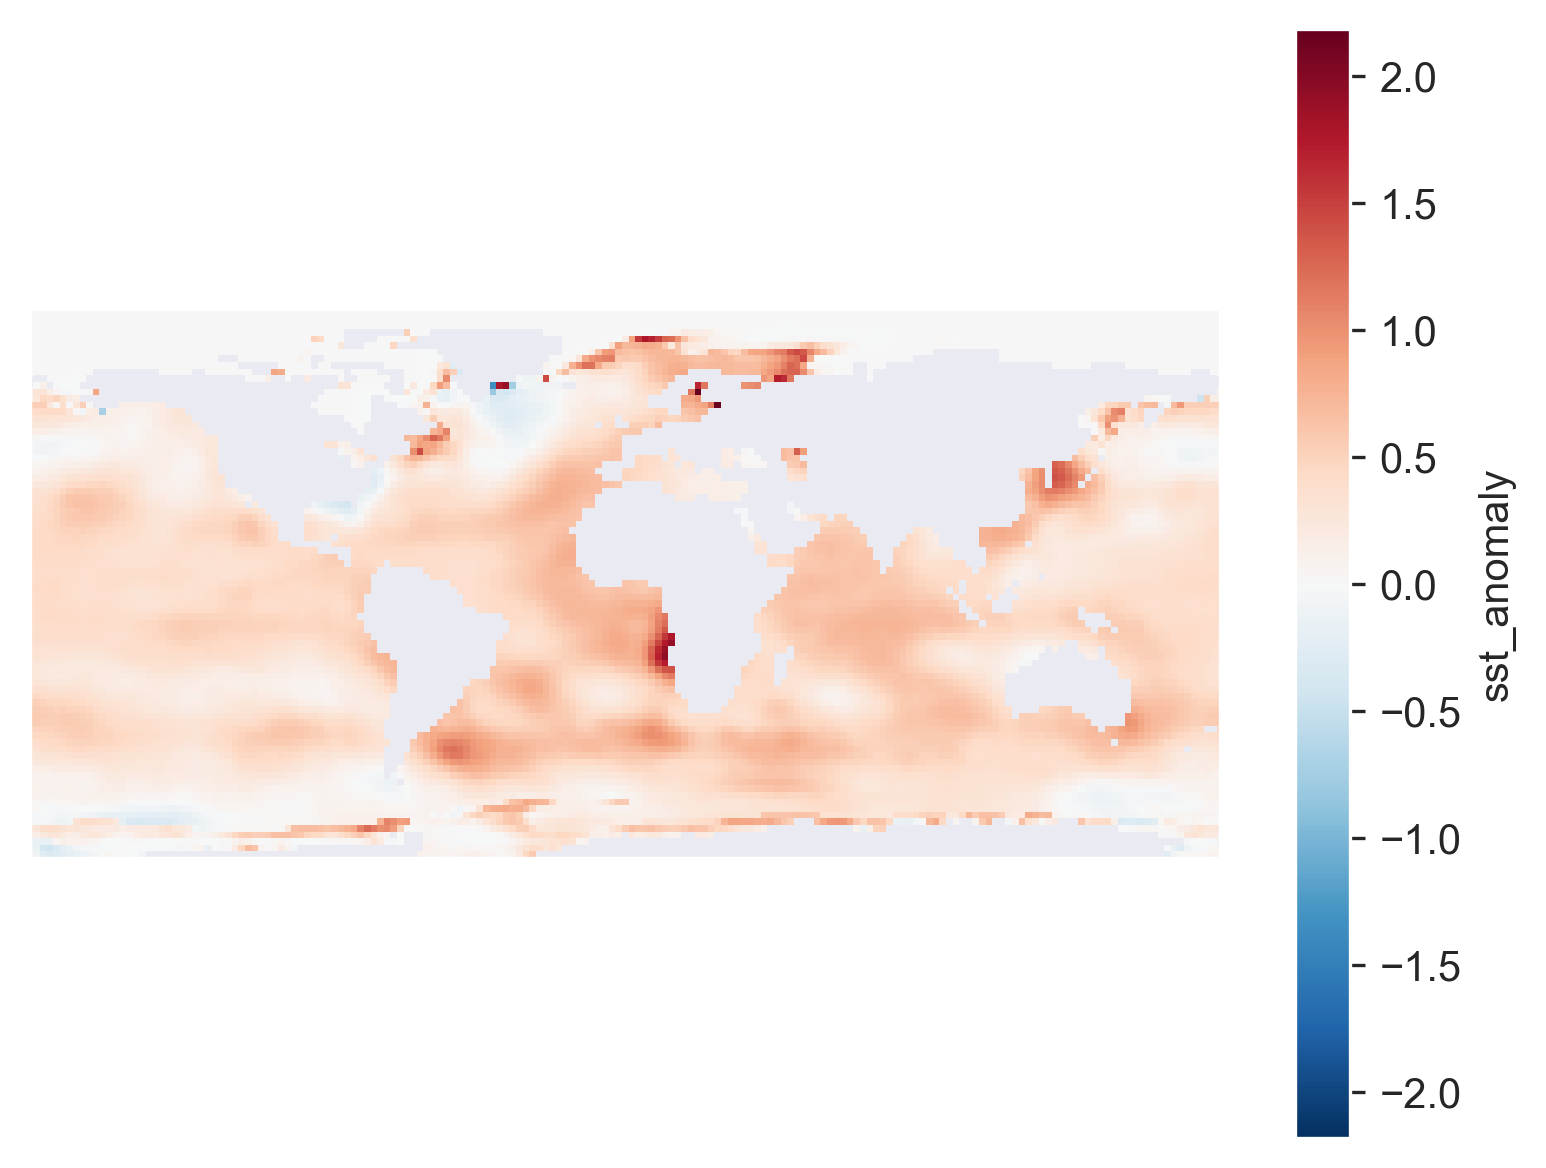

In [39]:
sst_df_jan_an.dropna().groupby(['lat', 'lon']).mean().reset_index().drop(['month', 'year', 'time'], axis=1).set_index(['lat', 'lon']).to_xarray()['sst_anomaly'].plot(
    subplot_kws=dict(projection=ccrs.PlateCarree()),
    transform=ccrs.PlateCarree()
)